In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

In [2]:
from dask.distributed import Client
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41413 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41413/status,
Dashboard: /proxy/41413/status,Workers: 7
Total threads: 7,Total memory: 256.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41487,Workers: 0
Dashboard: /proxy/41413/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39403,Total threads: 1
Dashboard: /proxy/44155/status,Memory: 36.57 GiB
Nanny: tcp://127.0.0.1:43645,


### Staggered grid (shared across all experiments)

In [3]:
Lx = 1000e3
Ly = 400e3
dx = 1000
dy = 1000
nx = int(Lx/dx)
ny = int(Ly/dy)
nxp = nx + 1
nyp = ny + 1

xh = np.linspace(dx/2, Lx - dx/2, nx)
yh = np.linspace(dy/2, Ly - dy/2, ny)
xq = np.linspace(0, Lx, nxp)
yq = np.linspace(0, Ly, nyp)

Xh, Yh   = np.meshgrid(xh, yh)
Xq, Yh_u = np.meshgrid(xq, yh)
Xh_v, Yq = np.meshgrid(xh, yq)

In [4]:
f = -1e-5
g = 9.81

### Velocity profile — computed once, shared across all experiments

All experiments (test52–test60) use the **same** tanh velocity profile and the **same** random noise realisation (fixed seed).

In [5]:
U    = 0.20
Ljet = 10e3
y0   = Ly / 2

yprime_h = (Yh   - y0) / Ljet
yprime_u = (Yh_u - y0) / Ljet
yprime_v = (Yq   - y0) / Ljet

u_clean = U * np.tanh(yprime_u)
v       = np.zeros((nyp, nx))

rng          = np.random.default_rng(seed=42)
random_noise = rng.standard_normal(u_clean.shape)
decay_factor = 1.0 / np.cosh(yprime_u)**2
noise        = 1e-3 * decay_factor * random_noise
u            = u_clean + noise

eta_t  = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t -= eta_t.mean()

zl   = 1
z    = np.array([-250.0])
h_3d = eta_t[np.newaxis, :, :]
u_3d = u    [np.newaxis, :, :]
v_3d = v    [np.newaxis, :, :]

print('Velocity and eta fields computed - shared by all experiments.')

Velocity and eta fields computed - shared by all experiments.


### Experiment loop — test52 to test60

**Fixed across all experiments:**
- Velocity profile: tanh (same as test41-51)
- Slope width: 50 grid cells, centred on cell 200, indices [175, 225)
- Shallow shelf depth: 100 m (flat from ny=0 up to slope start)

**Varies between experiments — slope height (depth drop across the slope):**
- Slope drops linearly from 100 m at the shelf edge to (100 + slope_height) m at the basin edge
- Beyond the slope, depth is flat at (100 + slope_height) m

| Experiment | Slope height (m) | Shelf depth (m) | Deep basin depth (m) |
|------------|-----------------|-----------------|----------------------|
| test52     | 25              | 100             | 125                  |
| test53     | 50              | 100             | 150                  |
| test54     | 100             | 100             | 200                  |
| test55     | 150             | 100             | 250                  |
| test56     | 200             | 100             | 300                  |
| test57     | 250             | 100             | 350                  |
| test58     | 300             | 100             | 400                  |
| test59     | 350             | 100             | 450                  |
| test60     | 375             | 100             | 475                  |

In [6]:
base_dir      = '/scratch/nm03/ae7501/mom6_input_directories/idealized'
shallow_depth = 100.0   # m - flat shelf depth (fixed for all experiments)
slope_width   = 50      # grid cells (fixed, even width -> centred on cell 200)
slope_start   = 175     # 200 - 50//2
slope_end     = 225     # slope_start + slope_width

# Slope heights: depth DROP across the slope.
# Deep basin depth = shallow_depth + slope_height.
slope_heights = [25, 50, 100, 150, 200, 250, 300, 350, 375]

experiments = [(112 + i, h) for i, h in enumerate(slope_heights)]


In [7]:

for exp_num, slope_height in experiments:

    exp_name   = f'test{exp_num}'
    input_dir  = os.path.join(base_dir, exp_name, 'INPUT')
    deep_depth = shallow_depth + slope_height

    os.makedirs(input_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f' {exp_name}  |  slope_height={slope_height}m  shelf={shallow_depth:.0f}m  basin={deep_depth:.0f}m')

    # Bathymetry:
    #   [0          : slope_start] flat at shallow_depth
    #   [slope_start : slope_end ] linear drop from shallow_depth to deep_depth
    #   [slope_end  :            ] flat at deep_depth
    depth_profile_y = np.zeros(ny)
    depth_profile_y[:slope_start]          = shallow_depth
    depth_profile_y[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width)
    depth_profile_y[slope_end:]            = deep_depth

    depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))
    print(f' slope [{slope_start}, {slope_end})  depth: {shallow_depth:.0f} -> {deep_depth:.0f} m')

    # --- init_vel.nc ---
    vel_path = os.path.join(input_dir, 'init_vel.nc')
    nc_vel = Dataset(vel_path, 'w', format='NETCDF4')
    nc_vel.createDimension('zl', zl)
    nc_vel.createDimension('yh', ny)
    nc_vel.createDimension('xh', nx)
    nc_vel.createDimension('yq', nyp)
    nc_vel.createDimension('xq', nxp)

    zl_v = nc_vel.createVariable('zl', 'f4', ('zl',))
    zl_v[:] = z ; zl_v.axis = 'Z' ; zl_v.long_name = 'depth to layer'

    xh_v = nc_vel.createVariable('xh', 'f4', ('xh',))
    xh_v[:] = xh ; xh_v.axis = 'X'
    xh_v.long_name = 'h-point longitude' ; xh_v.units = 'meters'

    yh_v = nc_vel.createVariable('yh', 'f4', ('yh',))
    yh_v[:] = yh ; yh_v.axis = 'Y'
    yh_v.long_name = 'h-point latitude' ; yh_v.units = 'meters'

    xq_v = nc_vel.createVariable('xq', 'f4', ('xq',))
    xq_v[:] = xq ; xq_v.axis = 'X'
    xq_v.long_name = 'q-point longitude' ; xq_v.units = 'meters'

    yq_v = nc_vel.createVariable('yq', 'f4', ('yq',))
    yq_v[:] = yq ; yq_v.axis = 'Y'
    yq_v.long_name = 'q-point latitude' ; yq_v.units = 'meters'

    u_var = nc_vel.createVariable('u', 'f4', ('zl', 'yh', 'xq'))
    u_var[:] = u_3d
    u_var.units = 'm s-1'
    u_var.long_name = 'Eastward velocity'
    u_var.standard_name = 'eastward_sea_water_velocity'

    v_var = nc_vel.createVariable('v', 'f4', ('zl', 'yq', 'xh'))
    v_var[:] = v_3d
    v_var.units = 'm s-1'
    v_var.long_name = 'Northward velocity'
    v_var.standard_name = 'northward_sea_water_velocity'

    nc_vel.regrid_method = 'bilinear'
    nc_vel.close()
    print(f' Written: {vel_path}')

    # --- init_eta.nc ---
    eta_path = os.path.join(input_dir, 'init_eta.nc')
    nc_h = Dataset(eta_path, 'w', format='NETCDF4')
    nc_h.createDimension('yh', ny)
    nc_h.createDimension('xh', nx)

    xh_v2 = nc_h.createVariable('xh', 'f4', ('xh',))
    xh_v2[:] = xh ; xh_v2.axis = 'X'
    xh_v2.long_name = 'h-point longitude' ; xh_v2.units = 'meters'

    yh_v2 = nc_h.createVariable('yh', 'f4', ('yh',))
    yh_v2[:] = yh ; yh_v2.axis = 'Y'
    yh_v2.long_name = 'h-point latitude' ; yh_v2.units = 'meters'

    h_var = nc_h.createVariable('eta_t', 'f4', ('yh', 'xh'))
    h_var[:] = h_3d
    h_var.units = 'm'
    h_var.long_name = 'Free surface height anomaly'
    h_var.standard_name = 'sea_floor_depth_below_sea_surface'

    nc_h.close()
    print(f' Written: {eta_path}')

    # --- ocean_topog.nc ---
    topo_path = os.path.join(input_dir, 'ocean_topog.nc')
    nc_d = Dataset(topo_path, 'w', format='NETCDF4')
    nc_d.createDimension('yh', ny)
    nc_d.createDimension('xh', nx)

    xh_d = nc_d.createVariable('xh', 'f4', ('xh',))
    xh_d[:] = xh
    xh_d.long_name = 't-cell center x-location' ; xh_d.units = 'meters'

    yh_d = nc_d.createVariable('yh', 'f4', ('yh',))
    yh_d[:] = yh
    yh_d.long_name = 't-cell center y-location' ; yh_d.units = 'meters'

    depth_var = nc_d.createVariable('depth', 'f4', ('yh', 'xh'))
    depth_var[:] = depth_2d
    depth_var.units = 'm'
    depth_var.long_name = 'ocean bottom depth'
    depth_var.standard_name = 'sea_floor_depth_below_geoid'

    nc_d.close()
    print(f' Written: {topo_path}')

print(f"\n{'='*60}")
print('All 9 experiments written successfully (test52-test60).')
print(f"{'='*60}")


 test112  |  slope_height=25m  shelf=100m  basin=125m
 slope [175, 225)  depth: 100 -> 125 m
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test112/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test112/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test112/INPUT/ocean_topog.nc

 test113  |  slope_height=50m  shelf=100m  basin=150m
 slope [175, 225)  depth: 100 -> 150 m
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test113/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test113/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test113/INPUT/ocean_topog.nc

 test114  |  slope_height=100m  shelf=100m  basin=200m
 slope [175, 225)  depth: 100 -> 200 m
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test114/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test114/INPUT/ini

### check plot — bathymetry profiles for all experiments

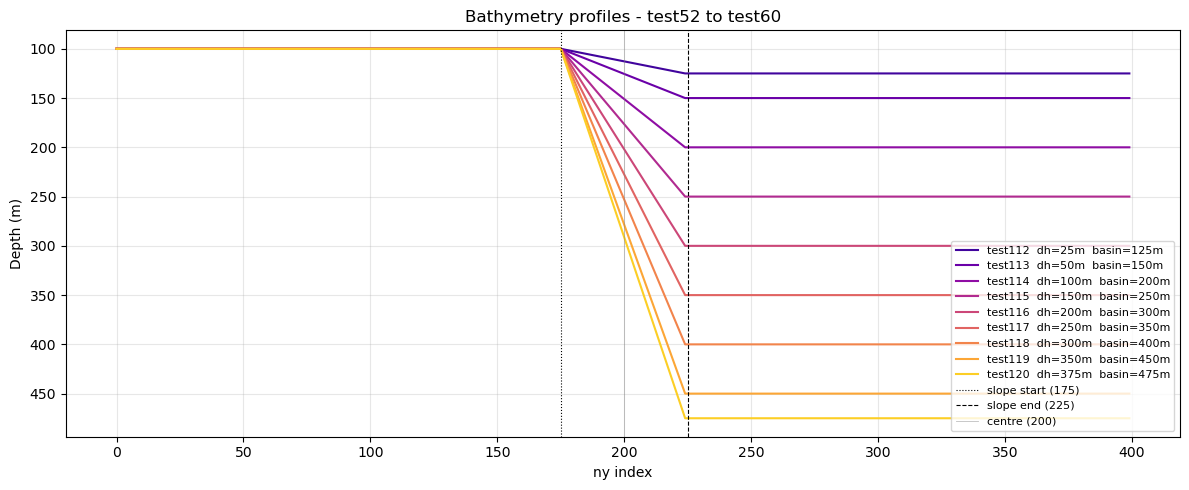

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(experiments)))

for i, (exp_num, slope_height) in enumerate(experiments):
    deep_depth = shallow_depth + slope_height

    profile = np.zeros(ny)
    profile[:slope_start]          = shallow_depth
    profile[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width)
    profile[slope_end:]            = deep_depth

    ax.plot(np.arange(ny), profile, color=colors[i],
            label=f'test{exp_num}  dh={slope_height}m  basin={deep_depth:.0f}m')

ax.axvline(slope_start, color='k', linestyle=':', linewidth=0.8, label=f'slope start ({slope_start})')
ax.axvline(slope_end,   color='k', linestyle='--', linewidth=0.8, label=f'slope end ({slope_end})')
ax.axvline(200,         color='gray', linestyle='-', linewidth=0.6, alpha=0.5, label='centre (200)')
ax.set_xlabel('ny index')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.set_title('Bathymetry profiles - test52 to test60')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()